### General Imports:


In [1]:
import os
import gymnasium as gym
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
from netsim.gym_basic.envs import MASKING_RMSA_ENV
from netsim.netSimPy import *
import numpy as np
import logging
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

logging.getLogger("tensorflow").setLevel(logging.FATAL)

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# FILES AND DIRECTORIES:
__file__ = "RF_RMSA.ipynb"
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split(".")[0]
log_dir = f"./tmp/{file_name}/"
# SIMULATION PARAMS:
EPISODE_LENGTH = 1000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 30000  # 300 Erlangs

networkPaths = "/Users/jbcedeno/Documents/projcts/multiband-gymnasium/networks/nsfnet"
network = Network(
    networkFileName=networkPaths + "/network.json",
    pathsFileName=networkPaths + "/routes.json",
    bitrateFilename=networkPaths + "/bitrates_c_bands.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
sim_args = dict(eventsGenerator=generator, network=network)
simulator = NetworkSimulator(**sim_args)
# Building the environment:
env_args = dict(
    simulator=simulator,
    episode_length=EPISODE_LENGTH,
    j=N_BLOCKS,
    n_paths=N_PATHS,
)

env: MASKING_RMSA_ENV = Monitor(gym.make("MASKING_RMSA_ENV-v0", **env_args), log_dir)
eval_env: MASKING_RMSA_ENV = Monitor(
    gym.make("MASKING_RMSA_ENV-v0", **env_args), log_dir + "eval_env"
)

best_model_dir = f"./tmp/ACTION_RMSA_ENV/best_smooth_model"
expert = MaskablePPO.load(best_model_dir)

In [3]:
from sklearn import ensemble
from netsim.explainable.common.dagger import Dagger
from netsim.explainable.common.beta import linear_beta
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.pipeline import make_pipeline


n_rounds = 8
beta_func = linear_beta(1, 0, n_rounds)

# model = make_pipeline(
#     RobustScaler(),
#     ensemble.RandomForestClassifier(class_weight="balanced", n_estimators=300),
# )

student = ensemble.RandomForestClassifier(class_weight="balanced", n_estimators=300)

dagger_trainer = Dagger(expert, student, env, beta_func)
model = dagger_trainer.train(n_rounds, timesteps_by_round=150000, n_evaluations=10000)
# Acceder al clasificador:

# student: ensemble.RandomForestClassifier = model.named_steps["randomforestclassifier"]

#
#

Starting round 1
Sampling new trajectories for round: {1} 


/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


0.888 [[1544   18    1    0    0  113  208    0    0    4]
 [   5 2916    0    0    0    6  190    0    0    0]
 [   0    0    3    0    0    0    2    0    0    0]
 [   0    0    0   41    1    0    0    0    0    0]
 [   0    0    0    0   17    0    0    0    0    0]
 [ 108    8    0    0    0 1278   97    0    0    0]
 [ 119  170    0    0    0   52 2888    0    2    0]
 [   0    0    0    0    1    0    0  100    0    0]
 [   3    0    0    0    0    0    0    0   40    0]
 [   8    4    0    0    0    0    0    0    0   53]]
Starting round 2
Sampling new trajectories for round: 2 
Fitting student for round: 2 
0.646 [[1870   48    0    0    0    0   10    0    1    1]
 [  19 3116    0    0    0    0    9    0    0    0]
 [   0    0    2    0    0    0    0    0    0    0]
 [   0    0    0   44    1    0    0    0    0    0]
 [   0    0    0    1   14    0    0    0    0    0]
 [ 951  109    0    0    0  352    6    0    0    0]
 [1063 1304    0    0    0    2  872    0    0    1]

### Saving the agent


In [4]:
import pickle as pkl

pickle_out = open("student_RF.pkl", "wb")
pkl.dump(student, pickle_out)
pickle_out.close()
# pickle_out = open("student_RF.pkl","rb")
# student = pkl.load(pickle_out)
# pickle_out.close()

### Global accuracy


In [5]:
from netsim.explainable.common.metrics import get_metrics
from netsim.explainable.common.rollout import generate_trajectories
from netsim.explainable.common.masking import predict_with_valid_classes, compute_mask

traj = generate_trajectories(200000, expert, env)
x_test = [t["obs"] for t in traj]
y_test = [int(t["action"]) for t in traj]

masking = compute_mask(env)
y_pred = predict_with_valid_classes(student, x_test, masking)
score = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred, labels=[i for i in range(15)])
print(f"Accuracy-score: {score}")
print(f'F1-score: {f1_score(y_test, y_pred, average="weighted")}')
print(conf_matrix)

Accuracy-score: 0.828865
F1-score: 0.8286356391160746
[[36894   342     0     0     0     0     0   315     0   664     1     0
      7     0     0]
 [  502 61710     0     0     0     0     0    43     0  1106     0     0
      0     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [   73     2     0    70     0     0     0     0     0    12     0     0
      0     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [    1     0     0     0     0   911    14     0     0     1     2     0
      0     0     0]
 [    1     0     0     0     0     6   356     1     0     0     3     0
      0     0     0]
 [ 9159   177     0     4     0     0     0 18000     0   593     0     2
      8     0     0]
 [    0     0     0     0     0     0     0     1     0     0     0     0
      0     0     0]
 [12994  7236     0     4     0     1     0   355     0 44195     2     1
      0     0    

In [6]:
get_metrics(conf_matrix)

Clase 1:
  Precision: 0.6140
  F1-score: 0.7506
  Sensibilidad (Recall): 0.9652
  Especificidad: 27.7607

Clase 2:
  Precision: 0.8872
  F1-score: 0.9286
  Sensibilidad (Recall): 0.9739
  Especificidad: 37.3773

Clase 3:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 4:
  Precision: 0.8974
  F1-score: 0.5957
  Sensibilidad (Recall): 0.4459
  Especificidad: 0.8046

Clase 5:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 6:
  Precision: 0.9891
  F1-score: 0.9849
  Sensibilidad (Recall): 0.9806
  Especificidad: 50.6111

Clase 7:
  Precision: 0.9393
  F1-score: 0.9544
  Sensibilidad (Recall): 0.9700
  Especificidad: 32.3636

Clase 8:
  Precision: 0.9616
  F1-score: 0.7715
  Sensibilidad (Recall): 0.6442
  Especificidad: 1.8103

Clase 9:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000

Clase 10:
  Precision: 0.9487
  F1-score: 0.7936
  Sensibilidad (Recall): 0.6821


/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/netsim/explainable/common/metrics.py:6: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(matrix) / np.sum(matrix, axis=0)
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/netsim/explainable/common/metrics.py:7: RuntimeWarning: invalid value encountered in divide
  recall = np.diag(matrix) / np.sum(matrix, axis=1)
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/netsim/explainable/common/metrics.py:8: RuntimeWarning: invalid value encountered in divide
  specificity = np.diag(matrix) / (np.sum(matrix, axis=1) - np.diag(matrix))


### Inter-path accuracy


In [7]:
n_conf_matrix = np.zeros(shape=(3, 3))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n_conf_matrix[ir // 5, ic // 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n_conf_matrix)
print(s[0])
print(n_conf_matrix)

0.83839
[[9.9593e+04 2.1400e+03 8.0000e+00]
 [2.9576e+04 6.4434e+04 1.8000e+01]
 [5.4900e+02 3.1000e+01 3.6510e+03]]


In [8]:
# Matriz de confusión proporcionada
n_conf_matrix = np.array(n_conf_matrix)

get_metrics(n_conf_matrix)

Clase 1:
  Precision: 0.7678
  F1-score: 0.8606
  Sensibilidad (Recall): 0.9789
  Especificidad: 46.3655

Clase 2:
  Precision: 0.9674
  F1-score: 0.8023
  Sensibilidad (Recall): 0.6853
  Especificidad: 2.1773

Clase 3:
  Precision: 0.9929
  F1-score: 0.9234
  Sensibilidad (Recall): 0.8629
  Especificidad: 6.2948



### Inter-spectrum accuracy


In [9]:
n2_conf_matrix = np.zeros(shape=(5, 5))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n2_conf_matrix[ir % 5, ic % 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n2_conf_matrix)
print(s[0])
print(n2_conf_matrix)

0.82896
[[3.9568e+04 3.6900e+02 3.2200e+02 0.0000e+00 6.6500e+02]
 [6.4900e+02 6.3048e+04 5.5000e+01 0.0000e+00 1.1070e+03]
 [9.4860e+03 2.6300e+02 1.8911e+04 4.0000e+00 6.0700e+02]
 [7.3000e+01 2.0000e+00 1.0000e+00 7.0000e+01 1.2000e+01]
 [1.2997e+04 7.2370e+03 3.5500e+02 4.0000e+00 4.4195e+04]]


In [10]:
# Matriz de confusión proporcionada
get_metrics(np.array(n2_conf_matrix))

Clase 1:
  Precision: 0.6303
  F1-score: 0.7631
  Sensibilidad (Recall): 0.9669
  Especificidad: 29.1799

Clase 2:
  Precision: 0.8890
  F1-score: 0.9287
  Sensibilidad (Recall): 0.9721
  Especificidad: 34.8139

Clase 3:
  Precision: 0.9627
  F1-score: 0.7732
  Sensibilidad (Recall): 0.6461
  Especificidad: 1.8254

Clase 4:
  Precision: 0.8974
  F1-score: 0.5932
  Sensibilidad (Recall): 0.4430
  Especificidad: 0.7955

Clase 5:
  Precision: 0.9487
  F1-score: 0.7936
  Sensibilidad (Recall): 0.6821
  Especificidad: 2.1461



In [11]:
def evaluate_bp_student(student, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.reset(options={"lambda": mLambda})
    observation = env.reset()[0]
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        # act = predict([observation], student, env)[0]
        act = predict_with_valid_classes(student, [observation], masking)[0]
        # act = student.predict([observation])[0]
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps


def evaluate_expert(expert, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.reset(options={"lambda": mLambda})
    observation = env.reset()
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        act, state = expert.predict(
            observation,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps

In [12]:
loads = [10000, 12500, 15000, 17500, 20000, 22500, 25000]
N_EVALUATIONS = 200000
lr_bp = []

for l in loads:
    bp = round(evaluate_bp_student(student, N_EVALUATIONS, l), 7)
    print(bp)
    lr_bp.append(bp)
print(lr_bp)

0.000105
8.5e-05
0.000255
0.000645
0.00172
0.00413
0.007335
[0.000105, 8.5e-05, 0.000255, 0.000645, 0.00172, 0.00413, 0.007335]


### features importance


[0.00125696 0.00128305 0.00150964 0.0177955  0.00154976 0.00095618
 0.00036734 0.00051149 0.00049857 0.00018223 0.00049954 0.00084907
 0.00114009 0.00134572 0.00124394 0.02681417 0.00143149 0.00165367
 0.00205223 0.00187195 0.00238883 0.00159991 0.00127993 0.00179559
 0.00101444 0.00087326 0.00072914 0.00266561 0.02100611 0.02354939
 0.02303133 0.01886603 0.01709275 0.01139242 0.01405174 0.00964694
 0.00990139 0.00725308 0.01301978 0.05456643 0.02714774 0.02605558
 0.0180236  0.05825042 0.05057007 0.01365493 0.00522354 0.01222261
 0.00606902 0.01667506 0.01065138 0.01514428 0.03779009 0.02027194
 0.03429106 0.03039821 0.05448422 0.05944855 0.0402788  0.03636552
 0.01426455 0.00815165 0.01003334 0.00486104 0.01362148 0.04257567
 0.03293897]


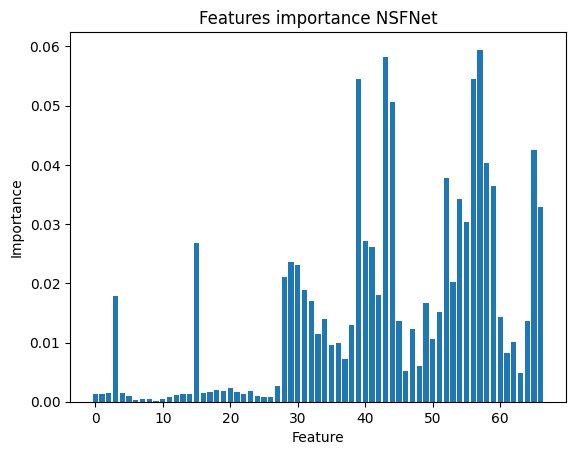

In [13]:
import pandas as pd

base_output_dir_features = f"./plots/{__file__}/features_importance_heuristic/"

output_dir = base_output_dir_features
os.makedirs(output_dir, exist_ok=True)

importances_sk = student.feature_importances_
importance = pd.DataFrame(importances_sk)
importance.to_csv(f"{output_dir}features_importance_heuristic.csv")
print(importances_sk)
plt.figure()
plt.bar([x for x in range(len(importances_sk))], importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Features importance NSFNet")
plt.savefig(output_dir + "NSFNet.png")
plt.show()